# Poisoning Experiment — Accuracy vs Poison Rate (full grid)
Sweep `poison_rate` ∈ {0, 0.25, 0.5, 0.75, 1.0} × 3 prompt types × 2 models con **k=5 fisso**.

Misura come la factual accuracy degrada al crescere del poisoning e se prompt type o modello
offrono robustezza differenziale (Strategy A — Zhou et al. 2024 §Robustness).

**Imposta `DRY_RUN = True` per validare il wiring (~90 chiamate), `False` per l'esperimento completo (~1.500 chiamate).**

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

with open("../configs/config.yaml") as f:
    cfg = yaml.safe_load(f)

DRY_RUN = False  # set True for a quick validation run (N=10)

SEED            = cfg["seed"]
K               = cfg["retrieval"]["k"]
DISTRACTOR_POOL = cfg["retrieval"]["distractor_pool_size"]
EMBEDDING_MODEL = cfg["retrieval"]["embedding_model"]
EMB_CACHE       = os.path.join("..", cfg["cache"]["dir"], cfg["cache"]["embeddings_subdir"])
LLM_CACHE       = os.path.join("..", cfg["cache"]["dir"], cfg["cache"]["llm_subdir"])

MODELS          = cfg["models"]["available"]
PROMPT_TYPES    = ["standard", "chain_of_thought", "vigilant"]
TEMPERATURE     = cfg["models"]["temperature"]
POISON_RATES    = [0.0, 0.25, 0.5, 0.75, 1.0]
N_EXAMPLES      = 10 if DRY_RUN else cfg["evaluation"]["n_examples"]

total_calls = len(POISON_RATES) * len(PROMPT_TYPES) * len(MODELS) * N_EXAMPLES
print(f"DRY_RUN={DRY_RUN}  n_examples={N_EXAMPLES}")
print(f"Grid: {len(POISON_RATES)} rates × {len(PROMPT_TYPES)} prompts × {len(MODELS)} models")
print(f"Estimated API calls: {total_calls}")

DRY_RUN=False  n_examples=50
Grid: 5 rates × 3 prompts × 2 models
Estimated API calls: 1500


In [2]:
from src.data.fever_loader import load_fever
from src.data.poisoner import poison_dataset
from src.retrieval.embedder import Embedder
from src.retrieval.retriever import Retriever
from src.generation.llm_client import AnthropicClient, OpenAIClient
from src.evaluation.scorer import run as run_scorer

all_examples = load_fever("../" + cfg["dataset"]["fever_dev"])
examples = all_examples[:N_EXAMPLES]
print(f"Total loaded: {len(all_examples):,}  |  Using: {len(examples)}")

Total loaded: 15,935  |  Using: 50


In [3]:
def build_llm(model: str):
    """Instantiate the right LLM client based on model name prefix."""
    if model.startswith("claude"):
        return AnthropicClient(model=model, temperature=TEMPERATURE, cache_dir=LLM_CACHE)
    return OpenAIClient(model=model, temperature=TEMPERATURE, cache_dir=LLM_CACHE)

In [4]:
def run_poisoning_sweep(examples, poison_rates, prompt_types, k, embedder, llm,
                        distractor_pool, seed):
    """Sweep poison_rates x prompt_types for a single open LLM client.

    Returns a list of row dicts (model, poison_rate, prompt_type, + metrics).
    embedder and llm must already be open (called within their context managers).
    """
    rows = []
    model_name = llm._model
    for poison_rate in poison_rates:
        poisoned = (
            poison_dataset(examples, poison_rate=poison_rate, seed=seed)
            if poison_rate > 0.0
            else examples
        )
        for prompt_type in prompt_types:
            retriever = Retriever(embedder=embedder, k=k)
            metrics = run_scorer(
                examples=poisoned,
                retriever=retriever,
                llm=llm,
                prompt_type=prompt_type,
                distractor_pool_size=distractor_pool,
                seed=seed,
                self_consistency_runs=1,
            )
            rows.append({"model": model_name, "poison_rate": poison_rate,
                         "prompt_type": prompt_type, **metrics})
            print(
                f"  {model_name.split('-')[0]:6s}  rate={poison_rate:.2f}  "
                f"prompt={prompt_type:15s}  acc={metrics['accuracy']:.3f}"
            )
    return rows

In [5]:
embedder = Embedder(model_name=EMBEDDING_MODEL, cache_dir=EMB_CACHE, device="cpu")
all_rows = []

print("Starting full grid sweep...")
for model_name in MODELS:
    print(f"\n--- Model: {model_name} ---")
    llm = build_llm(model_name)
    with llm:
        all_rows.extend(
            run_poisoning_sweep(
                examples=examples,
                poison_rates=POISON_RATES,
                prompt_types=PROMPT_TYPES,
                k=K,
                embedder=embedder,
                llm=llm,
                distractor_pool=DISTRACTOR_POOL,
                seed=SEED,
            )
        )

embedder.close()
results = pd.DataFrame(all_rows)
print(f"\nSweep done. {len(results)} conditions collected.")
results

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Starting full grid sweep...

--- Model: claude-haiku-4-5-20251001 ---
  claude  rate=0.00  prompt=standard         acc=0.840
  claude  rate=0.00  prompt=chain_of_thought  acc=0.780
  claude  rate=0.00  prompt=vigilant         acc=0.760
  claude  rate=0.25  prompt=standard         acc=0.700
  claude  rate=0.25  prompt=chain_of_thought  acc=0.640
  claude  rate=0.25  prompt=vigilant         acc=0.600
  claude  rate=0.50  prompt=standard         acc=0.660
  claude  rate=0.50  prompt=chain_of_thought  acc=0.640
  claude  rate=0.50  prompt=vigilant         acc=0.640
  claude  rate=0.75  prompt=standard         acc=0.680
  claude  rate=0.75  prompt=chain_of_thought  acc=0.680
  claude  rate=0.75  prompt=vigilant         acc=0.620
  claude  rate=1.00  prompt=standard         acc=0.600
  claude  rate=1.00  prompt=chain_of_thought  acc=0.600
  claude  rate=1.00  prompt=vigilant         acc=0.560

--- Model: gpt-4o-mini ---
  gpt     rate=0.00  prompt=standard         acc=0.800
  gpt     rate=0.

,model,poison_rate,prompt_type,accuracy,macro_f1,hallucination_rate,precision_at_k
0,claude-haiku-4-5-20251001,0.00,standard,0.84,0.839461,0.235294,0.208
1,claude-haiku-4-5-20251001,0.00,chain_of_thought,0.78,0.776398,0.411765,0.208
2,claude-haiku-4-5-20251001,0.00,vigilant,0.76,0.761141,0.352941,0.208
3,claude-haiku-4-5-20251001,0.25,standard,0.70,0.705238,0.235294,0.156
4,claude-haiku-4-5-20251001,0.25,chain_of_thought,0.64,0.646816,0.352941,0.156
5,claude-haiku-4-5-20251001,0.25,vigilant,0.60,0.610937,0.294118,0.156
6,claude-haiku-4-5-20251001,0.50,standard,0.66,0.661337,0.117647,0.132
7,claude-haiku-4-5-20251001,0.50,chain_of_thought,0.64,0.636905,0.117647,0.132
8,claude-haiku-4-5-20251001,0.50,vigilant,0.64,0.640000,0.058824,0.132
9,claude-haiku-4-5-20251001,0.75,standard,0.68,0.676883,0.000000,0.064


Saved → figures/03_accuracy_vs_poison_rate.png


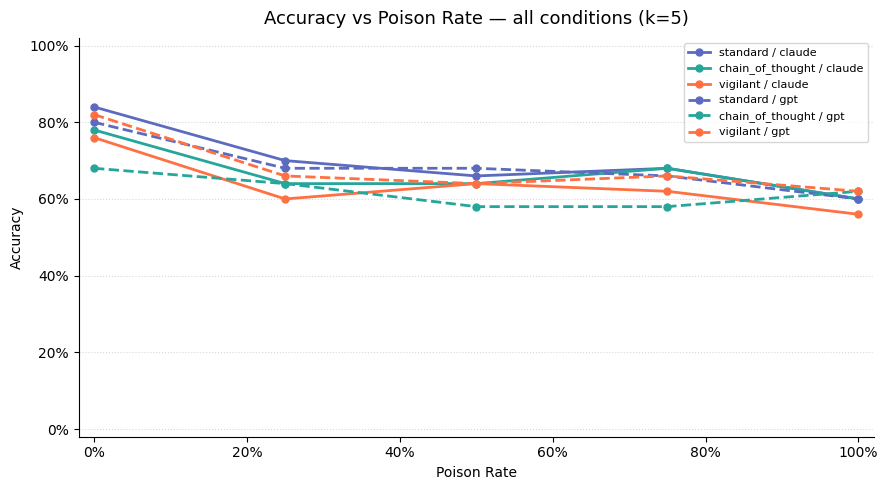

In [6]:
# 6 lines: 3 prompts × 2 models
# Color encodes prompt type; linestyle encodes model
PROMPT_COLORS = {
    "standard":        "#5C6BC0",
    "chain_of_thought": "#26A69A",
    "vigilant":        "#FF7043",
}
MODEL_LINESTYLES = {m: ("-" if i == 0 else "--") for i, m in enumerate(MODELS)}

fig, ax = plt.subplots(figsize=(9, 5))

for model in MODELS:
    for prompt in PROMPT_TYPES:
        sub = results[
            (results["model"] == model) & (results["prompt_type"] == prompt)
        ].sort_values("poison_rate")
        short_model = model.split("-")[0]
        ax.plot(
            sub["poison_rate"], sub["accuracy"],
            marker="o", linewidth=2, markersize=5,
            color=PROMPT_COLORS[prompt],
            linestyle=MODEL_LINESTYLES[model],
            label=f"{prompt} / {short_model}",
        )

ax.set_title(f"Accuracy vs Poison Rate — all conditions (k={K})", fontsize=13, pad=10)
ax.set_xlabel("Poison Rate")
ax.set_ylabel("Accuracy")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(fontsize=8, loc="upper right")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
if not DRY_RUN:
    plt.savefig("../figures/03_accuracy_vs_poison_rate.png", dpi=150, bbox_inches="tight")
    print("Saved → figures/03_accuracy_vs_poison_rate.png")
plt.show()

Saved → figures/03_hallucination_vs_poison_rate.png


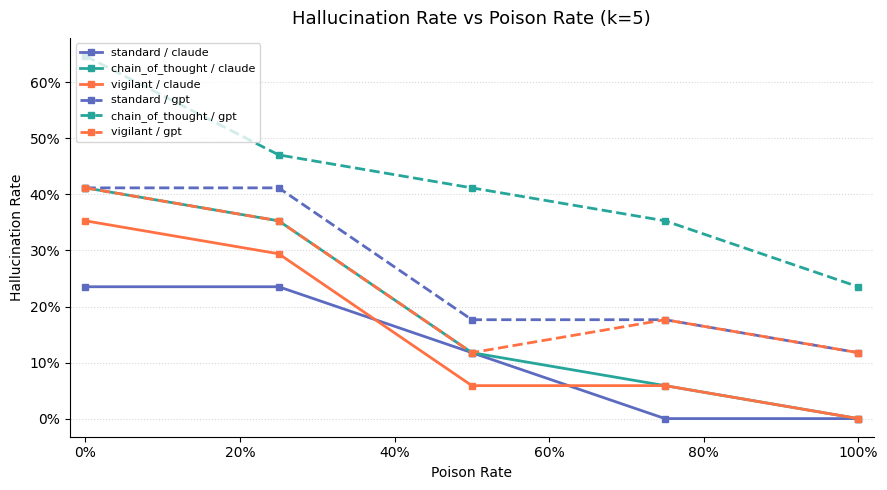

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

for model in MODELS:
    for prompt in PROMPT_TYPES:
        sub = results[
            (results["model"] == model) & (results["prompt_type"] == prompt)
        ].sort_values("poison_rate")
        short_model = model.split("-")[0]
        ax.plot(
            sub["poison_rate"], sub["hallucination_rate"],
            marker="s", linewidth=2, markersize=5,
            color=PROMPT_COLORS[prompt],
            linestyle=MODEL_LINESTYLES[model],
            label=f"{prompt} / {short_model}",
        )

ax.set_title(f"Hallucination Rate vs Poison Rate (k={K})", fontsize=13, pad=10)
ax.set_xlabel("Poison Rate")
ax.set_ylabel("Hallucination Rate")
ax.set_xlim(-0.02, 1.02)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(fontsize=8, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
if not DRY_RUN:
    plt.savefig("../figures/03_hallucination_vs_poison_rate.png", dpi=150, bbox_inches="tight")
    print("Saved → figures/03_hallucination_vs_poison_rate.png")
plt.show()

In [8]:
# Pivot: rows = (model, prompt_type), columns = poison_rate, values = accuracy
pivot = results.pivot_table(
    index=["model", "prompt_type"],
    columns="poison_rate",
    values="accuracy",
)
pivot.columns = [f"{c:.0%}" for c in pivot.columns]
pivot.index = pivot.index.map(lambda x: (x[0].split("-")[0], x[1]))
print("=== Accuracy pivot (rows: model × prompt, cols: poison_rate) ===")
print(pivot.to_string(float_format="{:.3f}".format))

print("\nKey takeaway: rows with least degradation = most robust condition.")

=== Accuracy pivot (rows: model × prompt, cols: poison_rate) ===
                           0%   25%   50%   75%  100%
model  prompt_type                                   
claude chain_of_thought 0.780 0.640 0.640 0.680 0.600
       standard         0.840 0.700 0.660 0.680 0.600
       vigilant         0.760 0.600 0.640 0.620 0.560
gpt    chain_of_thought 0.680 0.640 0.580 0.580 0.620
       standard         0.800 0.680 0.680 0.660 0.600
       vigilant         0.820 0.660 0.640 0.660 0.620

Key takeaway: rows with least degradation = most robust condition.
